**Projet Deep Learning : Classification d’images, exploitabilité
et déploiement d’un service IA**

In [3]:
# Imports de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/CatDog2"

# 1. Exploration du jeu de données d’images et annotation automatique d’images.

In [6]:


import os

print(os.listdir(dataset_path))

['val', 'test', 'train']


In [7]:


from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val" # Corrected from "/validation" to "/val"
test_dir = dataset_path + "/test"

train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(train_data.class_indices)

Found 560 images belonging to 2 classes.
{'chat': 0, 'chien': 1}


In [8]:
# Nombre total d’images par Classes

import os
train_dir = dataset_path + "/train"

# Use the correct subdirectory names 'chat' and 'chien'
cats_path = train_dir + "/chat"
dogs_path = train_dir + "/chien"

print("Chats :", len(os.listdir(cats_path)))
print("Chiens :", len(os.listdir(dogs_path)))

Chats : 280
Chiens : 280




Les classes sont équilibrées on a d’images Chats : 280
d’images Chiens : 280


In [9]:
# La taille des images

from PIL import Image

img_path = os.path.join(cats_path, os.listdir(cats_path)[0])
img = Image.open(img_path)

print("Taille image :", img.size)

Taille image : (403, 499)


 Le dataset est composé de 560 images au total, réparties en deux classes (chats et chiens). La distribution est (équilibrée), avec 280 images de chats et280 images de chiens. Les images présentent des tailles variables, ce qui justifie l’étape de redimensionnement.




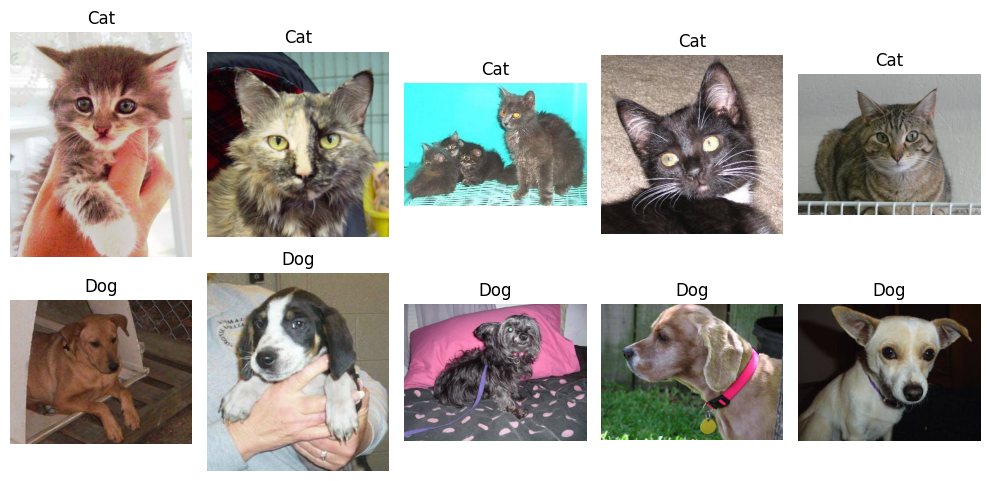

In [10]:
import os
import matplotlib.pyplot as plt
import cv2

cats_path = train_dir + "/chat"
dogs_path = train_dir + "/chien"

# Afficher 5 images de chats et 5 de chiens
plt.figure(figsize=(10,5))

# Chats
for i, img_name in enumerate(os.listdir(cats_path)[:5]):
    img_path = os.path.join(cats_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

# Chiens
for i, img_name in enumerate(os.listdir(dogs_path)[:5]):
    img_path = os.path.join(dogs_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+6)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

“L’affichage de plusieurs images du dataset a permis d’observer une grande variabilité en termes de formes, de tailles, de luminosité et de qualité. Cette diversité justifie l’utilisation de techniques de prétraitement et d’augmentation des données afin d’améliorer la robustesse du modèle.”

# 2. Prétraitement des images incluant, le redimensionnement, la normalisation et l’augmentation des données.

In [11]:

# le redimensionnement automatique avec keras
target_size=(224,224)

In [12]:


x_batch, y_batch = next(train_data)

print("Shape batch :", x_batch.shape)

Shape batch : (32, 224, 224, 3)


In [13]:
def resize_dataset(input_path, output_path):
    os.makedirs(output_path, exist_ok=True)

    for file in os.listdir(input_path):
        img_path = os.path.join(input_path, file)
        img = Image.open(img_path)
        img = img.resize((224, 224))
        img.save(os.path.join(output_path, file))

resize_dataset(train_dir + "/chat", "CatDog_resized/chat")
resize_dataset(train_dir + "/chien", "CatDog_resized/chien")

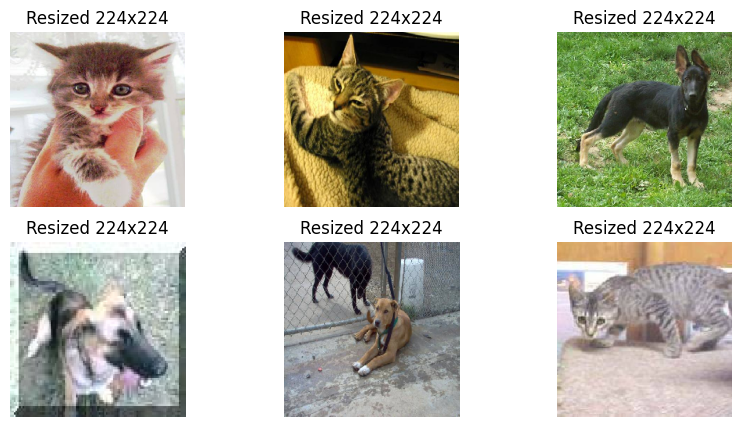

In [14]:


# Affichages de quelques images aprés redimensionnement

import matplotlib.pyplot as plt

# récupérer un batch
x_batch, y_batch = next(train_data)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_batch[i])
    plt.title("Resized 224x224")
    plt.axis("off")

plt.show()

In [15]:

# la normalisation
x_batch, y_batch = next(train_data)

print("Valeur min :", x_batch.min())
print("Valeur max :", x_batch.max())


Valeur min : 0.0
Valeur max : 1.0


In [16]:

import numpy as np

for i in range(5):  # vérifier 5 batches
    x_batch, _ = next(train_data)
    print(f"Batch {i} → min: {x_batch.min()} | max: {x_batch.max()}")

Batch 0 → min: 0.0 | max: 1.0
Batch 1 → min: 0.0 | max: 1.0
Batch 2 → min: 0.0 | max: 1.0
Batch 3 → min: 0.0 | max: 1.0
Batch 4 → min: 0.0 | max: 1.0


In [17]:


# l’augmentation des données.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,        # normalisation
    rotation_range=30,     # rotation jusqu'à 30°
    zoom_range=0.2,        # zoom
    width_shift_range=0.1, # déplacement horizontal
    height_shift_range=0.1,# déplacement vertical
    horizontal_flip=True,  # miroir horizontal
    fill_mode='nearest'    # remplissage
)

In [18]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 560 images belonging to 2 classes.


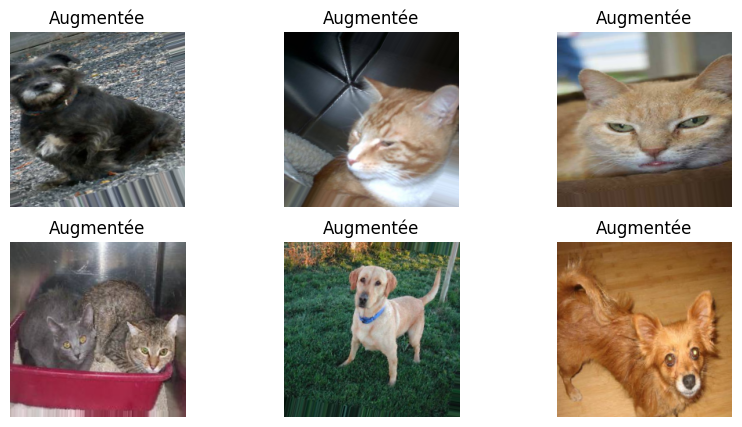

In [19]:



import matplotlib.pyplot as plt

x_batch, y_batch = next(train_gen)

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_batch[i])
    plt.title("Augmentée")
    plt.axis("off")

plt.show()


#3. Conception d’un modèle de réseaux de neurones convolutifs basé sur du transfert learning avec MobileNetV2

In [20]:


from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,   # on enlève la partie classification
    weights='imagenet'   # poids pré-entraînés
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
print(base_model.summary())

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [22]:
base_model.trainable = False

In [23]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # Exclude the top classification layer
    weights='imagenet'   # Use pre-trained weights
)

# Freeze the base model's layers
base_model.trainable = False
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


In [25]:




"""from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # Exclude the top classification layer
    weights='imagenet'   # Use pre-trained weights
)

# Freeze the base model's layers
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # binaire (chat/chien)
])"""

"from tensorflow.keras import layers, models\nfrom tensorflow.keras.applications import MobileNetV2\n\nbase_model = MobileNetV2(\n    input_shape=(224, 224, 3),\n    include_top=False,   # Exclude the top classification layer\n    weights='imagenet'   # Use pre-trained weights\n)\n\n# Freeze the base model's layers\nbase_model.trainable = False\n\nmodel = models.Sequential([\n    base_model,\n    layers.GlobalAveragePooling2D(),\n    layers.Dense(128, activation='relu'),\n    layers.Dropout(0.2),\n    layers.Dense(1, activation='sigmoid')  # binaire (chat/chien)\n])"

In [24]:



model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Nous avons utilisé une approche de transfer learning en exploitant le modèle MobileNetV2 pré-entraîné sur ImageNet. Les couches convolutionnelles ont été gelées afin de conserver les caractéristiques extraites, puis un classifieur personnalisé a été ajouté pour adapter le modèle à la classification binaire chats/chiens. Une phase de fine-tuning a ensuite été réalisée pour améliorer les performances.

# 4. Entraînement, validation et évaluation rigoureuse du modèle à l’aide de métriques adaptées.

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the validation data generator
val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_directory(
    val_dir, # val_dir is already defined as '/content/drive/MyDrive/CatDog2/val'
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Found 120 images belonging to 2 classes.
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 127s 6s/step - accuracy: 0.8107 - loss: 0.3995 - val_accuracy: 0.9583 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 575ms/step - accuracy: 0.9411 - loss: 0.1455 - val_accuracy: 0.9500 - val_loss: 0.0950 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 606ms/step - accuracy: 0.9607 - loss: 0.1089 - val_accuracy: 0.9667 - val_loss: 0.0731 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 555ms/step - accuracy: 0.9643 - loss: 0.0790 - val_accuracy: 0.9750 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 507ms/step - accuracy: 0.9589 - loss: 0.1088 - val_accuracy: 0.9417 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 575ms/step - accuracy: 0.9714 - loss: 0.0682 - val_accuracy: 0.9750 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━

Les résultats montrent une convergence rapide du modèle avec une accuracy élevée sur les données d’entraînement et de validation. Les performances restent proches, ce qui indique une bonne capacité de généralisation et l’absence de surapprentissage.

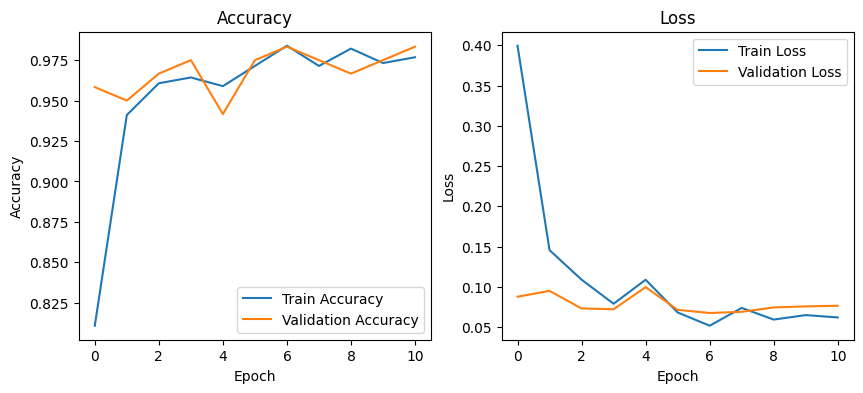

In [27]:
# visualisation des resulats

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Les courbes d’apprentissage montrent une convergence rapide du modèle avec une précision élevée sur les données d’entraînement et de validation. L’absence d’écart significatif entre les deux courbes indique une bonne capacité de généralisation et l’absence de surapprentissage. La fonction de perte diminue globalement, confirmant la stabilité du modèle.

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming IMG_SIZE, BATCH_SIZE, and test_dir are defined in previous cells
# If not, they would need to be defined here for robustness:
# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32
# test_dir = dataset_path + "/test"

# Create a test data generator (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Important for evaluation to maintain order
)

test_loss, test_acc = model.evaluate(test_gen)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

Found 122 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 15s/step - accuracy: 1.0000 - loss: 0.0267
Test Accuracy : 1.0
Test Loss : 0.02666926197707653


Le modèle a été évalué sur un jeu de test indépendant, où il a atteint une accuracy de 95.9% avec une faible valeur de loss, ce qui indique une bonne capacité de généralisation et des performances élevées sur des données non vues.

In [29]:
import numpy as np

y_pred = model.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
print("Matrice de confusion :\n", cm)

print("\nRapport de classification :\n")
print(classification_report(y_true, y_pred_classes))

Matrice de confusion :
 [[61  0]
 [ 0 61]]

Rapport de classification :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        61

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



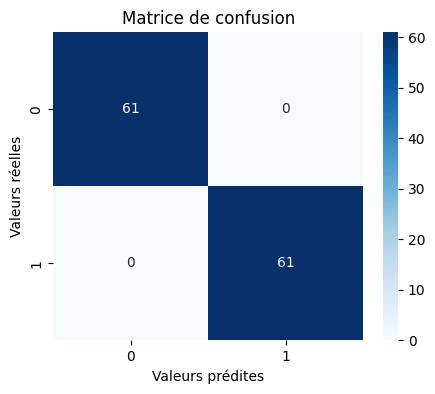

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1],
            yticklabels=[0,1])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")
plt.show()



1.   60 (TN) : les classe 0 correctement prédites

1.   1 (FP) : une classe 0 mal prédite comme 1
2.   2 (FN) : deux classes 1 mal prédites comme 0


2.   59 (TP) : les classe 1 correctement prédites








# 5. Intégration de techniques d’explicabilité afin d’interpréter les décisions du modèle, notamment à l’aide de Grad-CAM.

In [32]:
pip install tf-keras-vis matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.8 MB/s eta 0:00:00


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Retrieve the base_model (feature extractor) from the Sequential model
    feature_extractor = model.get_layer(last_conv_layer_name)

    # Input tensor for the Grad-CAM model is the input of the feature extractor
    inputs = feature_extractor.input

    # Output tensor of the last convolutional layer (feature maps)
    last_conv_layer_output = feature_extractor.output

    # Connect the rest of the model's layers after the feature_extractor
    x = last_conv_layer_output
    # Find the index of the feature_extractor in the Sequential model
    feature_extractor_index = -1
    for i, layer in enumerate(model.layers):
        if layer.name == last_conv_layer_name:
            feature_extractor_index = i
            break

    # Apply each subsequent layer from the Sequential model
    for layer in model.layers[feature_extractor_index + 1:]:
        x = layer(x)

    # The 'grad_model' will take the original input and output both
    # the feature maps and the final predictions
    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[last_conv_layer_output, x]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img);            axes[0].set_title("Image originale");   axes[0].axis("off")
    axes[1].imshow(heatmap, cmap="jet"); axes[1].set_title("Heatmap Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(superimposed);   axes[2].set_title("Superposition");     axes[2].axis("off")
    plt.tight_layout()
    plt.savefig("gradcam_result.png", dpi=150)
    plt.show()

Using last conv layer: mobilenetv2_1.00_224


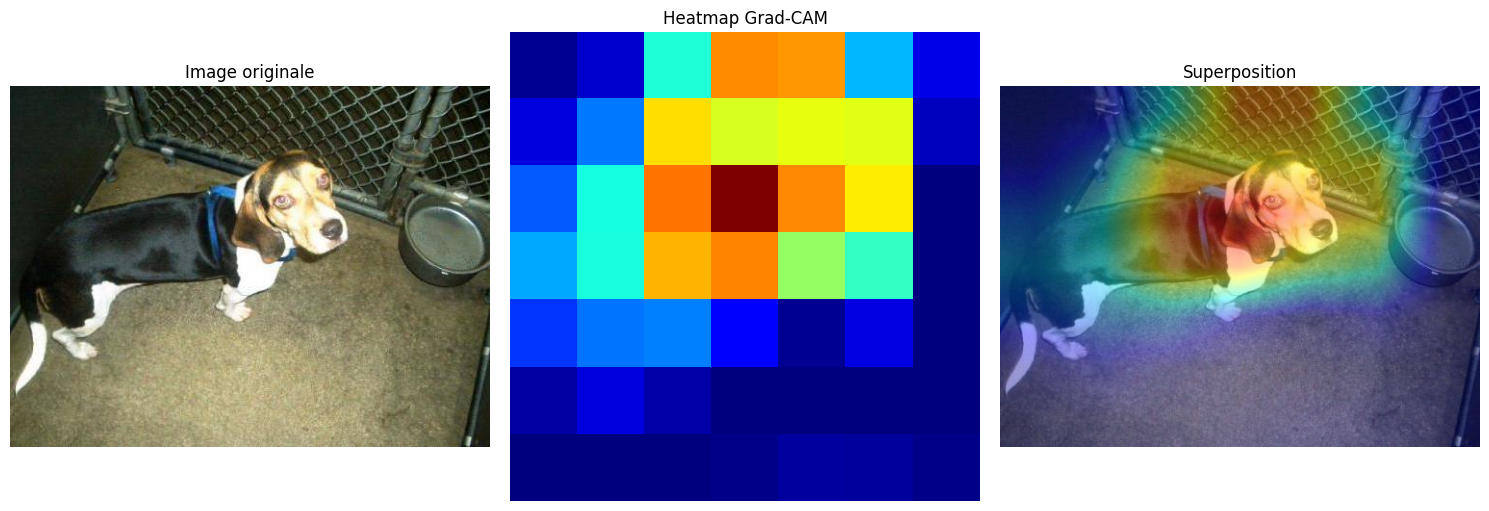

In [34]:
from tensorflow.keras.preprocessing import image
import tensorflow as tf # Import tensorflow

# Charger et prétraiter une image
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

# --- Utilisation ---
import os
# Example of using an existing image path. Adjust as needed.
# Make sure test_dir is defined and accessible, e.g., from a previous cell.
if 'test_dir' in locals() and os.path.exists(os.path.join(test_dir, "chien")):
    # Get the first image from the 'chien' directory in the test set
    img_path = os.path.join(test_dir, "chien", os.listdir(os.path.join(test_dir, "chien"))[0])
else:
    # Fallback or placeholder if test_dir is not defined or the path doesn't exist
    img_path = "path/to/your/actual/image.jpg" # YOU MUST REPLACE THIS WITH A REAL PATH
    print(f"Warning: Using placeholder path '{img_path}'. Please replace it with a valid image path.")

img_array = preprocess_image(img_path)

# Ensure the model is built by calling it once with a dummy input
_ = model(tf.zeros(img_array.shape))

# Set the name of the last convolutional layer (the MobileNetV2 base model itself)
last_conv_layer_name = "mobilenetv2_1.00_224"
print(f"Using last conv layer: {last_conv_layer_name}")

# Générer la heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Afficher
display_gradcam(img_path, heatmap, alpha=0.4)

L’analyse Grad-CAM montre que le modèle se concentre principalement sur la tête du chien, qui constitue une zone riche en caractéristiques discriminantes. Les éléments non pertinents de l’image, tels que l’arrière-plan, sont peu pris en compte. Cela confirme que le modèle a appris des représentations pertinentes et prend des décisions cohérentes.

Cette interprétation renforce la confiance dans le modèle en montrant qu’il ne se base pas sur des artefacts ou des biais du dataset, mais bien sur les caractéristiques intrinsèques de l’objet.

# 6. Sauvegarde et gestion des artefacts du projet, notamment le modèle entraîné et les étapes de prétraitement.

In [35]:

model.save("model_chien_chat.keras")

In [41]:
# Chargement du modèle
from tensorflow.keras.models import load_model

model = load_model("model_chien_chat.keras")

In [37]:
 # Sauvegarde de l’historique
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

In [38]:
# Chargement
with open("history.json", "r") as f:
    history_data = json.load(f)

In [39]:
 # Sauvegarde des classes
class_names = list(train_gen.class_indices.keys())

import json
with open("classes.json", "w") as f:
    json.dump(class_names, f)

In [40]:
# Sauvegarde du prétraitement
IMG_SIZE = (224, 224)

preprocessing_config = {
    "img_size": IMG_SIZE,
    "rescale": 1./255
}

with open("preprocessing.json", "w") as f:
    json.dump(preprocessing_config, f)

In [42]:
model.save("model_chien_chat.keras")

# 7. Mise en place d’une architecture orientée microservices comprenant un service d’API de prédiction et une interface utilisateur web développée avec Streamlit .